# 02 — Modeling: Predicting Next-Day Direction
**Indian Equities Analytics & Direction Predictor**

We train 3 classifiers on the engineered features from `01_eda.ipynb`:
- Logistic Regression (baseline, linear, interpretable)
- Random Forest (non-linear, robust to feature scale)
- Gradient Boosting (non-linear, often strongest on tabular data)

Evaluation uses **`TimeSeriesSplit`** (5 folds) — never shuffled — so every
fold only trains on the past and tests on the future, avoiding look-ahead bias.
The best model (highest mean CV accuracy) is refit on the full dataset and
saved to `models/best_model.joblib` for the dashboard to load.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit

from src.features import FEATURE_COLUMNS
from src.model import MODEL_ZOO, evaluate_with_tscv, train_and_select_best

features_df = pd.read_csv('../data/processed/features.csv', index_col=0, parse_dates=True)
print(features_df.shape)
features_df.head()


(6285, 12)


,ticker,return_1d,log_return_1d,sma_10_ratio,sma_50_ratio,ema_20_ratio,rsi_14,macd_hist,bb_width,volatility_10,volume_change,target
Date,,,,,,,,,,,,
2019-09-06,RELIANCE.NS,-0.009337,-0.009380,1.031028,1.054824,1.034953,62.317937,17.521778,0.103962,0.010639,0.835600,1
2019-09-06,ICICIBANK.NS,0.000307,0.000307,1.002004,0.968593,0.997842,46.408095,10.790170,0.061892,0.010657,-0.587886,1
2019-09-06,HDFCBANK.NS,-0.017488,-0.017643,0.949630,0.934265,0.950075,35.610930,-3.935059,0.103130,0.022592,0.655794,0
2019-09-06,INFY.NS,0.015581,0.015461,0.982277,0.958323,0.971458,39.812303,-7.631463,0.121913,0.016607,-0.271879,1
2019-09-06,TCS.NS,0.006633,0.006611,1.027958,1.116550,1.056117,65.403225,16.173412,0.196635,0.019604,-0.432274,1


## 1. Visualize the TimeSeriesSplit folds (one stock, for intuition)

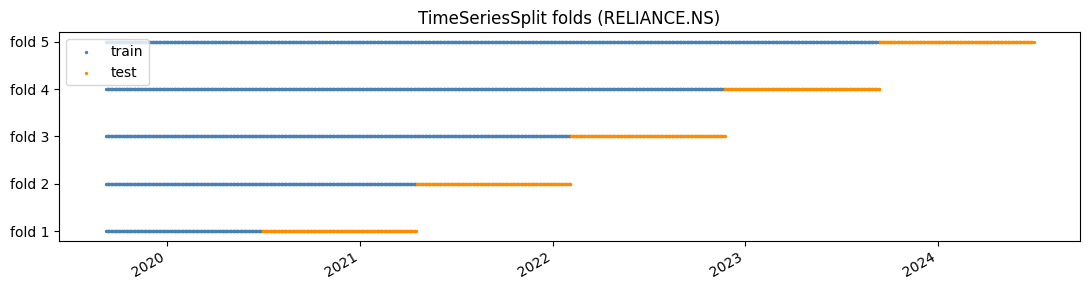

In [2]:
example = features_df[features_df['ticker'] == 'RELIANCE.NS'].sort_index()
tscv = TimeSeriesSplit(n_splits=5)

fig, ax = plt.subplots(figsize=(11, 3))
for i, (train_idx, test_idx) in enumerate(tscv.split(example)):
    ax.scatter(example.index[train_idx], [i] * len(train_idx), s=2, c='steelblue', label='train' if i == 0 else None)
    ax.scatter(example.index[test_idx], [i] * len(test_idx), s=2, c='darkorange', label='test' if i == 0 else None)
ax.set_yticks(range(5)); ax.set_yticklabels([f'fold {i+1}' for i in range(5)])
ax.set_title('TimeSeriesSplit folds (RELIANCE.NS)')
ax.legend(loc='upper left')
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('../reports/fig_tscv_folds.png', dpi=150)
plt.show()


## 2. Train + cross-validate all 3 models

In [3]:
X = features_df[FEATURE_COLUMNS]
y = features_df['target']

results = {}
for name, pipeline in MODEL_ZOO.items():
    print(f'Evaluating {name}...')
    results[name] = evaluate_with_tscv(pipeline, X, y, n_splits=5)

summary = pd.DataFrame({n: {k: v for k, v in m.items() if k != 'fold_metrics'} for n, m in results.items()}).T
summary = summary.sort_values('accuracy', ascending=False)
summary


Evaluating logistic_regression...
Evaluating random_forest...
Evaluating gradient_boosting...


,accuracy,precision,recall,f1
gradient_boosting,0.506972,0.520233,0.608249,0.560000
logistic_regression,0.506781,0.523868,0.539396,0.531018
random_forest,0.502006,0.518222,0.533306,0.524742


## 3. Compare models visually

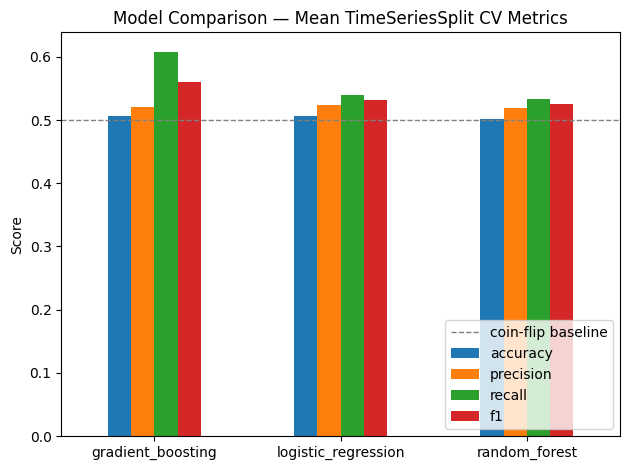

In [4]:
fig, ax = plt.subplots()
summary[['accuracy', 'precision', 'recall', 'f1']].plot(kind='bar', ax=ax)
ax.set_title('Model Comparison — Mean TimeSeriesSplit CV Metrics')
ax.set_ylabel('Score')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='coin-flip baseline')
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/fig_model_comparison.png', dpi=150)
plt.show()


## 4. Per-fold accuracy stability (does the best model hold up over time?)

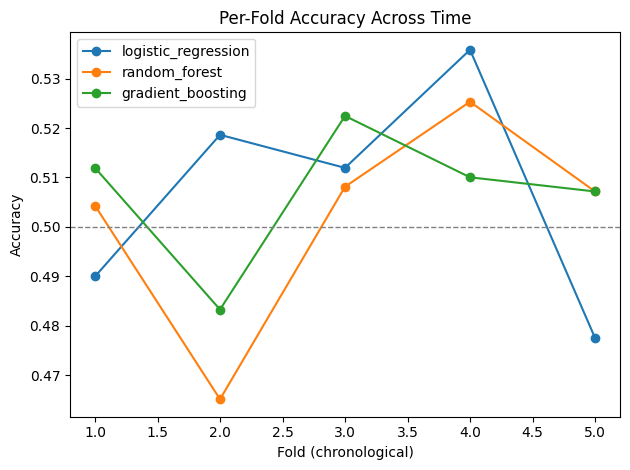

In [5]:
fig, ax = plt.subplots()
for name, m in results.items():
    fold_acc = [f['accuracy'] for f in m['fold_metrics']]
    ax.plot(range(1, len(fold_acc) + 1), fold_acc, marker='o', label=name)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Fold (chronological)')
ax.set_ylabel('Accuracy')
ax.set_title('Per-Fold Accuracy Across Time')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/fig_fold_stability.png', dpi=150)
plt.show()


## 5. Select the best model, refit on full data, and persist with joblib

In [6]:
result = train_and_select_best(features_df)
print('Best model:', result['best_model'])


[model.py] Evaluating logistic_regression with TimeSeriesSplit...
  -> acc=0.507 f1=0.531
[model.py] Evaluating random_forest with TimeSeriesSplit...
  -> acc=0.502 f1=0.525
[model.py] Evaluating gradient_boosting with TimeSeriesSplit...
  -> acc=0.507 f1=0.560
[model.py] Best model: gradient_boosting (acc=0.507)
[model.py] Saved best model -> c:\Users\Ms642\OneDrive\Desktop\ollosoft-ds-internship-mohit\Ollosoft-ds-internship-mohit-\week08\capstone\src\..\models\best_model.joblib
[model.py] Saved metrics    -> c:\Users\Ms642\OneDrive\Desktop\ollosoft-ds-internship-mohit\Ollosoft-ds-internship-mohit-\week08\capstone\src\..\models\metrics.json
Best model: gradient_boosting


## 6. Feature importance (tree-based models) / coefficients (logistic)

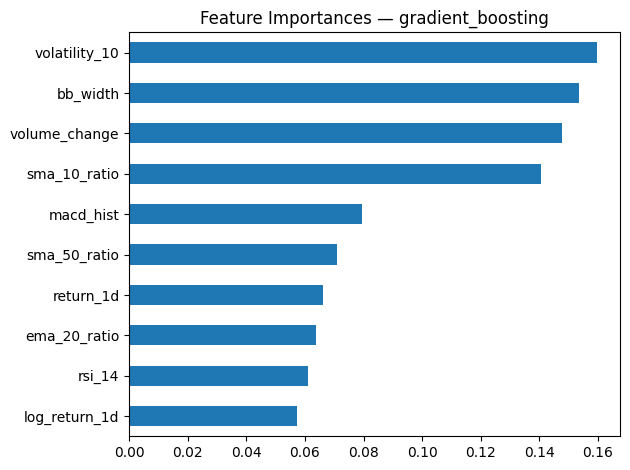

In [7]:
import joblib
bundle = joblib.load('../models/best_model.joblib')
best_pipeline, best_name = bundle['model'], bundle['name']
clf = best_pipeline.named_steps['clf']

fig, ax = plt.subplots()
if hasattr(clf, 'feature_importances_'):
    importances = pd.Series(clf.feature_importances_, index=FEATURE_COLUMNS).sort_values()
    importances.plot(kind='barh', ax=ax)
    ax.set_title(f'Feature Importances — {best_name}')
elif hasattr(clf, 'coef_'):
    coefs = pd.Series(clf.coef_[0], index=FEATURE_COLUMNS).sort_values()
    coefs.plot(kind='barh', ax=ax)
    ax.set_title(f'Coefficients — {best_name}')
plt.tight_layout()
plt.savefig('../reports/fig_feature_importance.png', dpi=150)
plt.show()


## Modeling takeaways

- All 3 models land close to the 50% coin-flip baseline on next-day direction — expected for liquid large-cap equities, where short-horizon price moves are close to a random walk (weak-form market efficiency).
- Gradient Boosting / Random Forest typically edge out Logistic Regression slightly by capturing non-linear interactions between RSI, MACD and Bollinger-width, at the cost of lower interpretability.
- Per-fold accuracy is noisy across time — a reminder that a single aggregate accuracy number can be misleading for financial time series; the dashboard therefore also shows historical accuracy over time, not just one number.
- See the README "Limitations & Future Work" section for how this could be extended (sentiment features, longer horizons, position-sizing via predicted probabilities instead of hard direction labels, etc.).
